In [1]:
import sys, os
from pathlib import Path
# --- project bootstrap ---------------------------------------------------
# This notebook lives under notebooks/<pre|post>_training/, but it imports the
# my_image_jepa modules (dataset, model, eval, losses, lars, scheduler) and
# reads paths relative to the my_image_jepa root (./data, ./checkpoints, cfgs/).
# Walk up to that root (the dir holding main.py + cfgs/) and make it both the
# working directory and an import root, so the notebook runs from anywhere.
from pathlib import Path

ROOT = Path.cwd()
while not ((ROOT / "main.py").exists() and (ROOT / "cfgs").is_dir()) and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")

project root: /Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa


In [2]:
artifact_dir = '/Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa/artifacts/image_jepa_checkpoint:v0'

import torch
ckpt = torch.load(f"{artifact_dir}/latest.pth.tar", map_location="cpu")

In [3]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


from dataset import get_train_transforms

base_train_dataset = CIFAR10(
        root= "./data", train=True, download=False, 
    )

In [4]:
from dataset import ImageDataset

train_transform = get_train_transforms()
train_dataset = ImageDataset(base_train_dataset,train_transform,2)
train_loader = DataLoader(train_dataset,batch_size=2,shuffle=False)

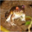

In [5]:
base_train_dataset[0][0]

In [6]:
batch = next(iter(train_loader))
(view1,view2),label = batch

print(view1.shape,view2.shape)


torch.Size([2, 3, 32, 32]) torch.Size([2, 3, 32, 32])


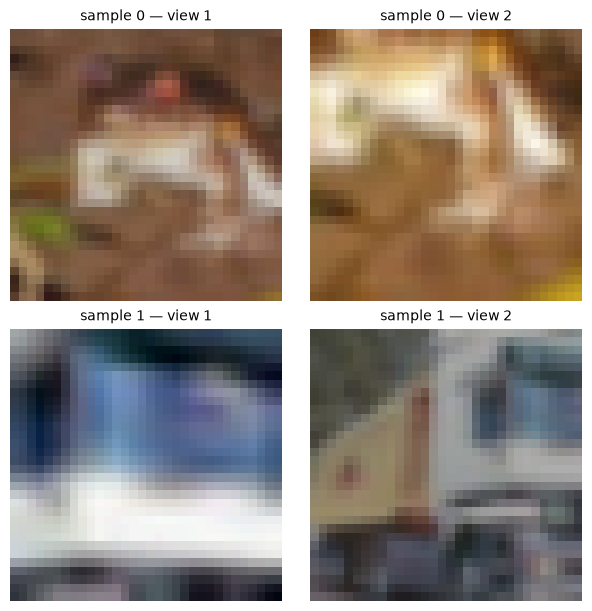

In [7]:
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def denorm(img):
    return (img * std + mean).clamp(0, 1)   # back to [0, 1]

def show_views(view1, view2, max_images=4):
    """Gallery of both views: one row per sample, capped at max_images.

    view1, view2: [B, 3, H, W] batches of the two augmented views.
    """
    n = min(view1.shape[0], max_images)
    if view1.shape[0] > max_images:
        print(f"note: batch has {view1.shape[0]} samples, showing the first {max_images}")

    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n), constrained_layout=True, squeeze=False)

    for row in range(n):
        for col, view in enumerate([view1, view2]):
            ax = axes[row][col]
            ax.imshow(denorm(view[row]).permute(1, 2, 0).cpu().numpy())
            ax.set_title(f"sample {row} — view {col + 1}", fontsize=10)
            ax.axis("off")

    plt.show()

show_views(view1, view2)

In [8]:
from model import ResNet18, ImageSSL

backbone = ResNet18()

model = ImageSSL(
    backbone= backbone,
    features_dim= backbone.features_dim
)

model.load_state_dict(ckpt["model_state_dict"])


<All keys matched successfully>

In [9]:


model.eval()
with torch.no_grad():
    for batch in train_loader:
        (view0,view1),label = batch
        features_1, z1 = model(view0)
        features_2, z2 = model(view1)
        break


In [10]:
print(features_1.shape,z1.shape)
print(features_2.shape,z2.shape)

print(features_1.min(),features_1.max())
print(features_2.min(),features_2.max())

torch.Size([2, 512]) torch.Size([2, 2048])
torch.Size([2, 512]) torch.Size([2, 2048])
tensor(0.) tensor(1.7381)
tensor(0.) tensor(1.7233)


In [11]:
sys.path.insert(0, str(Path.cwd() / "notebooks" / "post_training"))
from feature_scales import compute_global_color_scales

In [ ]:
global_vmax, global_dmax, global_sdmax, global_diffmax = compute_global_color_scales(
    train_dataset, model
)

# global_vmax = 

device: mps
activation, single neuron                      | p99 : 0.9203 | max : 12.4715
across-view diff  |view1 - view2|, same image  | p99 : 0.3808 | max : 6.9896
across-sample diff  |this image - next image|  | p99 : 1.1332 | max : 11.7539


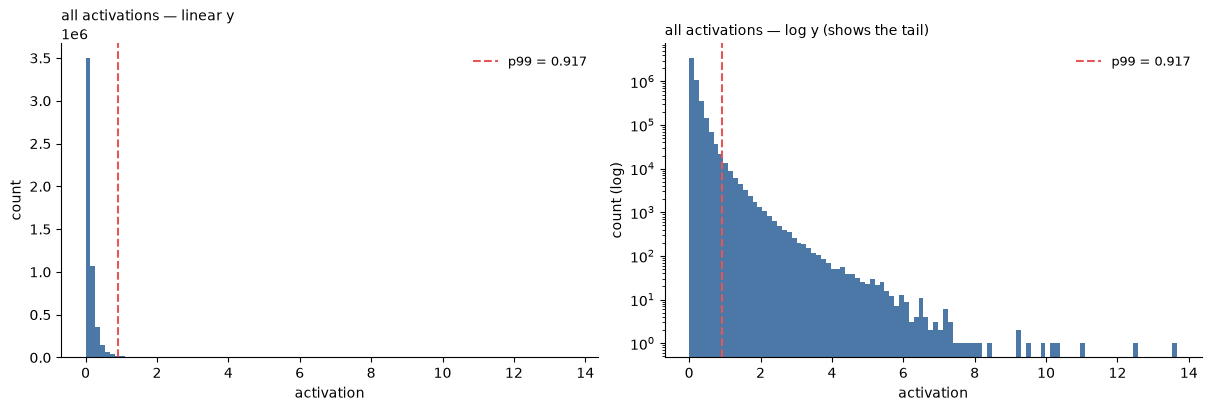

exact zeros: 32.3% of all values
mean: 0.1238, median: 0.0497
p99: 0.9168, max: 13.6746


In [13]:
from feature_scales import plot_activation_distribution

# distribution of neuron activations over a sample of the train set, with the p99
# color ceiling marked. see feature_scales.plot_activation_distribution for details.
acts, p99 = plot_activation_distribution(train_dataset, model)

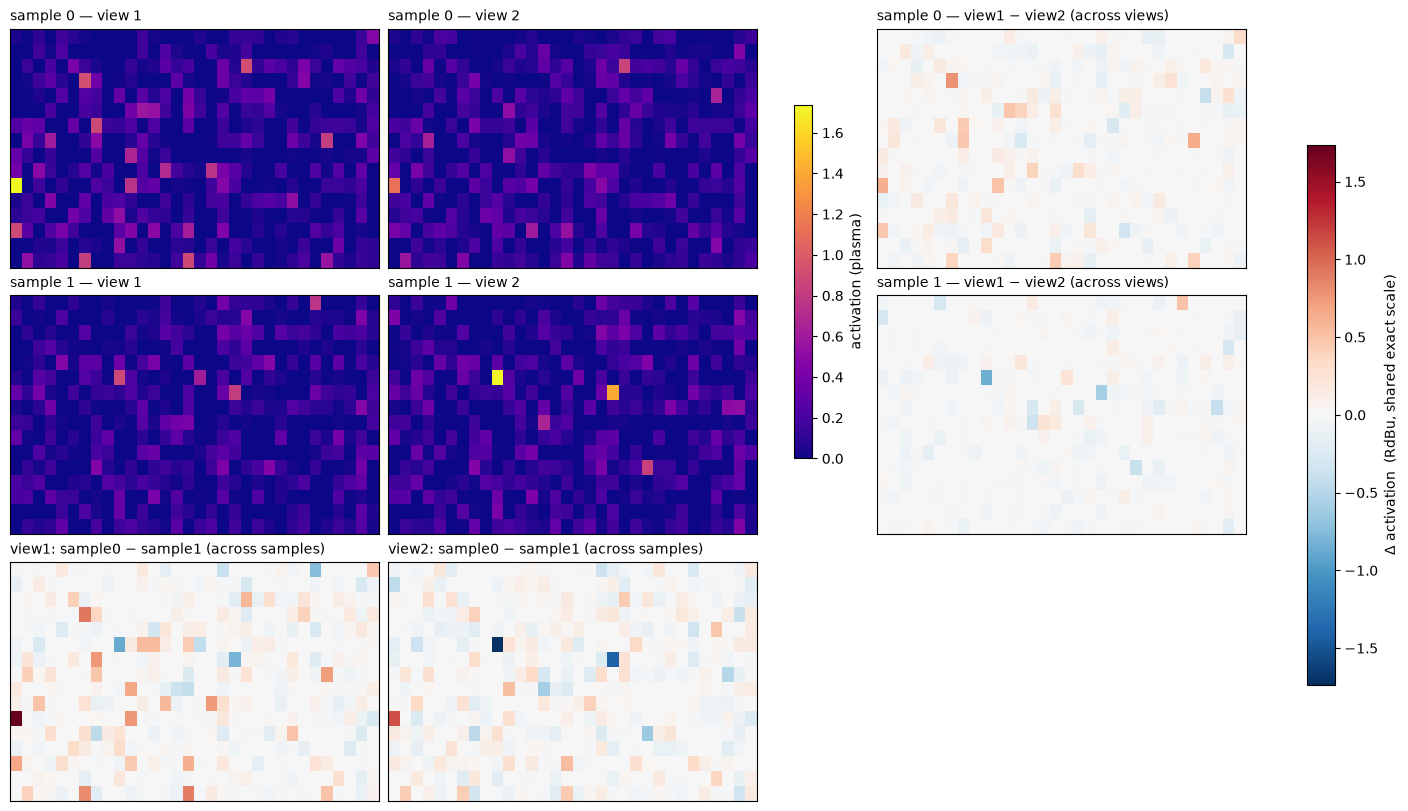

activation vmax: 1.7381   shared diff |max|: 1.7381


In [21]:
import numpy as np

# 3x3 grid:
#   row 0: sample0 view1 | sample0 view2 | sample0 view1-view2 (across views)
#   row 1: sample1 view1 | sample1 view2 | sample1 view1-view2 (across views)
#   row 2: view1 sample0-sample1 | view2 sample0-sample1 (across samples) | (empty)
# So each across-view diff sits to the RIGHT of its two view panels, and each across-
# sample diff sits BELOW its view column. Activations in plasma; every diff in RdBu
# (diverging, symmetric about 0). All diffs SHARE one exact symmetric scale, so the same
# color means the same delta (across views vs across samples are directly comparable).
grid = (16, 32)
f1 = features_1[:2].numpy().reshape(2, *grid)   # view 1 for [sample0, sample1]
f2 = features_2[:2].numpy().reshape(2, *grid)   # view 2 for [sample0, sample1]

view_diff = f1 - f2                              # across-view, per sample (row)
samp_diff = np.stack([f1[0] - f1[1],             # across-sample, view 1: sample0 - sample1
                      f2[0] - f2[1]])            # across-sample, view 2: sample0 - sample1

vmax = float(max(f1.max(), f2.max()))           # activation ceiling (exact)
diffmax = float(max(np.abs(view_diff).max(),    # ONE symmetric exact scale for every diff
                    np.abs(samp_diff).max()))

fig, axes = plt.subplots(3, 3, figsize=(14, 8), constrained_layout=True, squeeze=False)

# rows 0-1: activations (cols 0-1, plasma) + across-view diff (col 2, RdBu)
for row in range(2):
    for col, (f, title) in enumerate([(f1, "view 1"), (f2, "view 2")]):
        ax = axes[row][col]
        im = ax.imshow(f[row], cmap="plasma", vmin=0.0, vmax=vmax, aspect="auto")
        ax.set_title(f"sample {row} — {title}", fontsize=10, loc="left")
        ax.set_xticks([])
        ax.set_yticks([])
    ax_v = axes[row][2]
    im_d = ax_v.imshow(view_diff[row], cmap="RdBu_r", vmin=-diffmax, vmax=diffmax, aspect="auto")
    ax_v.set_title(f"sample {row} — view1 − view2 (across views)", fontsize=10, loc="left")
    ax_v.set_xticks([])
    ax_v.set_yticks([])

# row 2: across-sample diff, each under its own view column (col 0 = view1, col 1 = view2)
for col, title in enumerate(["view1: sample0 − sample1", "view2: sample0 − sample1"]):
    ax_s = axes[2][col]
    im_d = ax_s.imshow(samp_diff[col], cmap="RdBu_r", vmin=-diffmax, vmax=diffmax, aspect="auto")
    ax_s.set_title(f"{title} (across samples)", fontsize=10, loc="left")
    ax_s.set_xticks([])
    ax_s.set_yticks([])
axes[2][2].axis("off")   # no diff-of-diff panel here

act_axes = [axes[0][0], axes[0][1], axes[1][0], axes[1][1]]
diff_axes = [axes[0][2], axes[1][2], axes[2][0], axes[2][1]]
cbar = fig.colorbar(im, ax=act_axes, shrink=0.7)
cbar.set_label("activation (plasma)")
cbar_d = fig.colorbar(im_d, ax=diff_axes, shrink=0.7)
cbar_d.set_label("Δ activation  (RdBu, shared exact scale)")
plt.show()

print(f"activation vmax: {vmax:.4f}   shared diff |max|: {diffmax:.4f}")